**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance


In [59]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve, recall_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsClassifier

First, let's import datasets and y-target, created earlier:

In [3]:
with open('X_padel_dropped.pickle', 'rb') as input:
    X_padel_dropped = pickle.load(input)

In [4]:
with open('X_standard_dropped.pickle', 'rb') as input:
    X_standard_dropped = pickle.load(input)

In [5]:
with open('y.pickle', 'rb') as input:
    target = pickle.load(input)


In [6]:
with open('X_standard_pca.pickle', 'rb') as input:
    X_standard_pca = pickle.load(input)

In [7]:
with open('X_padel_pca.pickle', 'rb') as input:
    X_padel_pca = pickle.load(input)

To facilitate automatic calculation of metrics and asiggning labels, we weill create dictionaries with imported descriptors datasets (standard datasets and datasetes with reduced dimensionality)

In [8]:
descriptors_dict = {'Standard':X_standard_dropped, 'Padel':X_padel_dropped}

In [9]:
descriptors_dict_pca = {'Standard':X_standard_pca, 'Padel':X_padel_pca}

The function below performs multiple tasks:
1. First, it create matplotlib figure object and axes with two fields,
2. Then for each of two datasets in descriptors dictionary (standard and PCA), we:
    - Create a pipeline, made of MinMaxScaler and algorithm,
    - Split dataset into training and testing subsets;
    - Then we search for optimal parameters with functions from [hyperopt package](http://hyperopt.github.io/hyperopt/);
    - Then we extract the best model and train it with X_train and y_train;
    - Then we claculate different metrics (Accuracy, F1-Score, ROC_AUC score) and append it to the special dictionary with results, as well as some information abour descriptors sets and name of studied algorithm
    - Finally, we plot ROC-AUC curve 

In [73]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = descriptors_dict, target=target, type = 'Full'):
    fig, axes = plt.subplots(1, 2, figsize = (12,8))
    i = 0
    for key, value in descriptors_dict.items():
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        def objective(params, X, target):
            pipe = make_pipeline(MinMaxScaler(), estimator)
            pipe.set_params(**params)
            score = cross_val_score(pipe, X, target, cv = 5, scoring = 'precision')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe}
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  50)
        print(best)
        best_estimator  = get_best_model_from_trials(trials) 
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        probs = best_estimator.predict_proba(X_test)[:,1]
        scores['Descriptors'].append(key)
        scores['Accuracy'].append(accuracy_score(y_test, predictions))
        scores['F1 - score'].append(f1_score(y_test, predictions))
        scores['ROC-AUC Score'].append(roc_auc_score(y_test, probs))
        scores['Recall score'].append(recall_score(y_test, predictions))
        scores['Precision score'].append(precision_score(y_test, predictions))
        scores['Full or PCA'].append(type)
        scores['Estimator'].append(estimator_name)
        fpr, tpr, _ = roc_curve(y_test, probs)
        axes[i].plot(fpr, tpr)
        axes[i].plot([0,1],[0,1], 'k--')
        axes[i].set_title('ROC-AUC Curve for {} descriptors'.format(key))
        axes[i].set_xlabel('False positive rate')
        axes[i].set_ylabel('True positive rate')
        i += 1
    plt.tight_layout()

Subfunction below is to retrieve best model from Trials object ans is used in main functions

In [74]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['Trained_model']

Let's initialize scores dictionary and test function with Logistic Regression

In [75]:
scores = {'Descriptors':[], 'Full or PCA':[], 'Accuracy':[], 'F1 - score':[], 'ROC-AUC Score':[], 'Estimator':[], 'Recall score':[], 'Precision score':[]}

100%|██████████| 50/50 [00:23<00:00,  2.14trial/s, best loss: -0.7365237758424659]
{'C': 88.9928912026425}
100%|██████████| 50/50 [00:17<00:00,  2.78trial/s, best loss: -0.734882907752473] 
{'C': 1.4402244942634146}


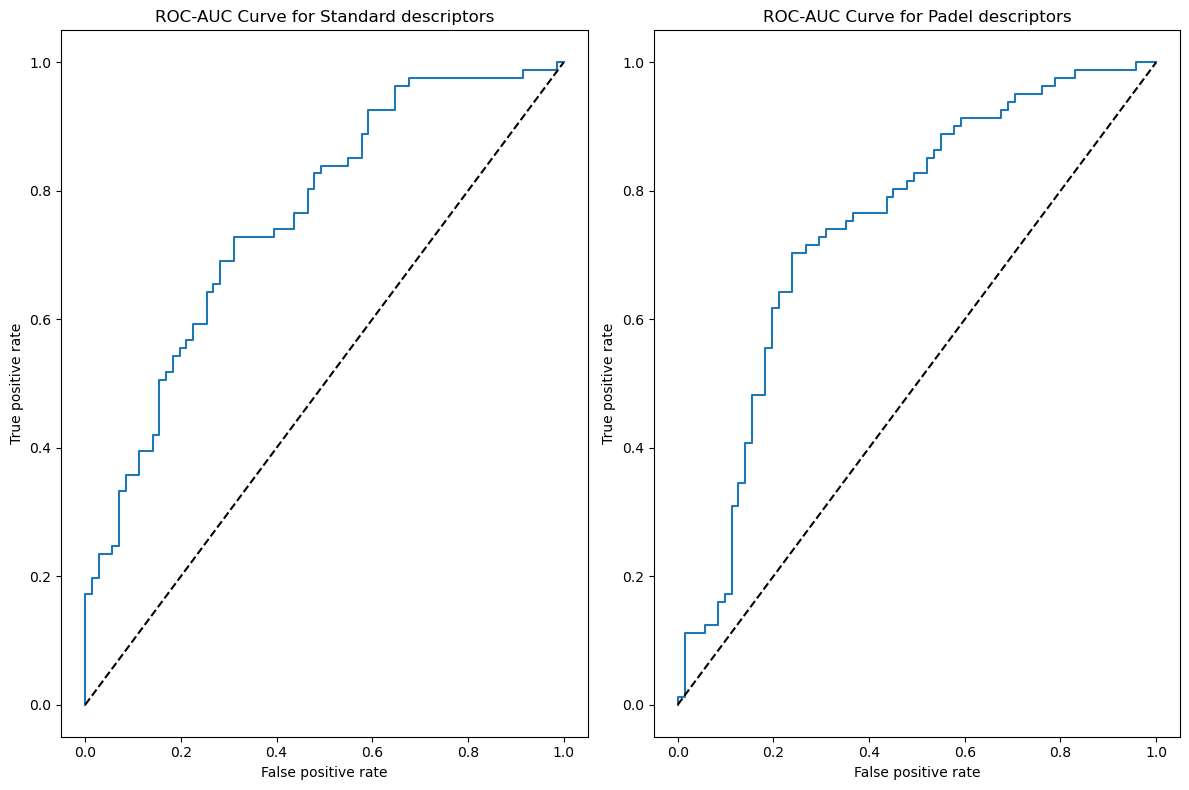

In [76]:
calculate_to_score(LogisticRegression(random_state = 0, max_iter = 1000), estimator_name='Logistic Regression', 
                   param_grid = {'logisticregression__C':hp.loguniform(label = 'C', low = -4*np.log(10), high  = 2*np.log(10))})

100%|██████████| 50/50 [00:06<00:00,  7.81trial/s, best loss: -0.6205800060496067]
{'C': 0.5001601862384278}
100%|██████████| 50/50 [00:05<00:00,  8.72trial/s, best loss: -0.5253724053724054]
{'C': 0.0011034495454792005}


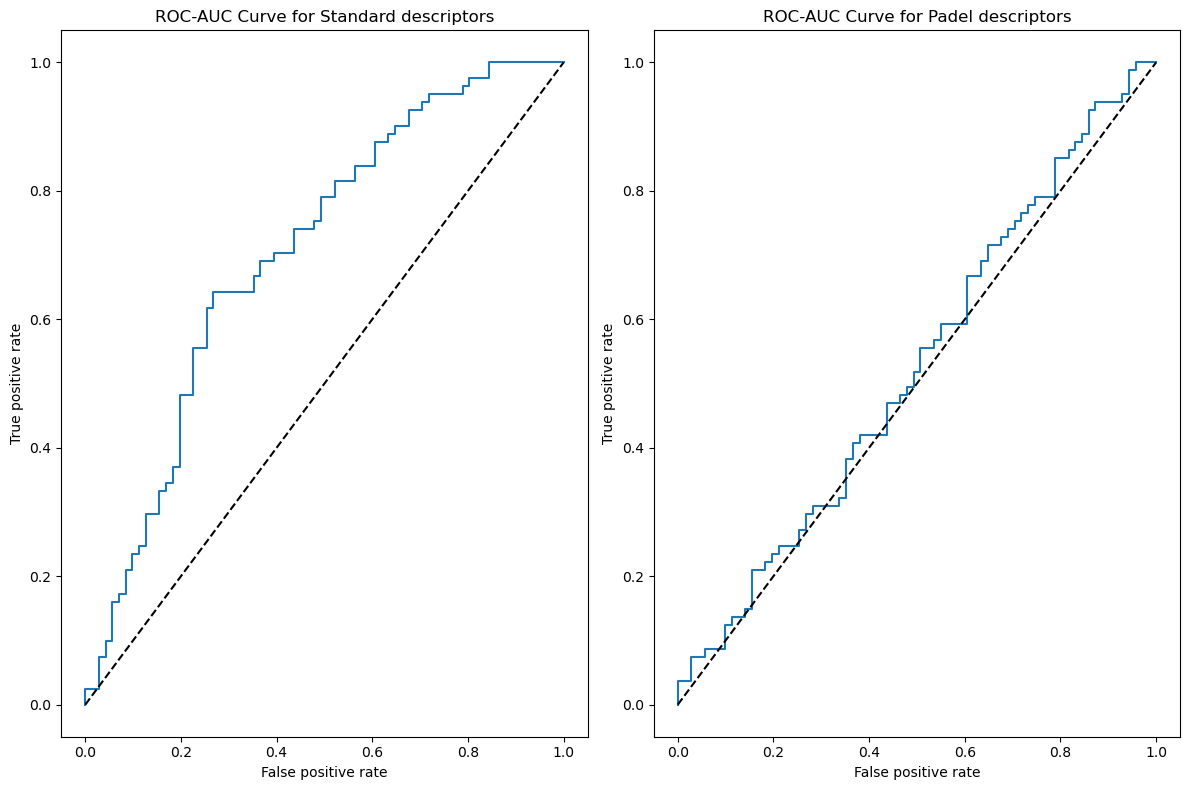

In [78]:
calculate_to_score(LogisticRegression(random_state = 0, max_iter = 1000), estimator_name='Logistic Regression', 
                   param_grid = {'logisticregression__C':hp.loguniform(label = 'C', low = -4*np.log(10), high  = 2*np.log(10))},
                  descriptors_dict=descriptors_dict_pca, type = 'PCA')

Let's continue with other models. The first one will be
**Random Forest Classification**

In [79]:
space={'randomforestclassifier__max_depth':hp.randint('max_depth',1,50),  'randomforestclassifier__max_features':hp.choice('max_features', [None, 'sqrt', 'log2']),
       'randomforestclassifier__min_samples_split':hp.randint('min_samples_split', 2, 8),
       'randomforestclassifier__min_samples_leaf': hp.randint('min_samples_leaf', 1, 10)}

100%|██████████| 50/50 [01:32<00:00,  1.85s/trial, best loss: -0.808623716153128] 
{'max_depth': 12, 'max_features': 0, 'min_samples_leaf': 3, 'min_samples_split': 6}
100%|██████████| 50/50 [01:32<00:00,  1.85s/trial, best loss: -0.8226637463496036]
{'max_depth': 46, 'max_features': 0, 'min_samples_leaf': 1, 'min_samples_split': 2}


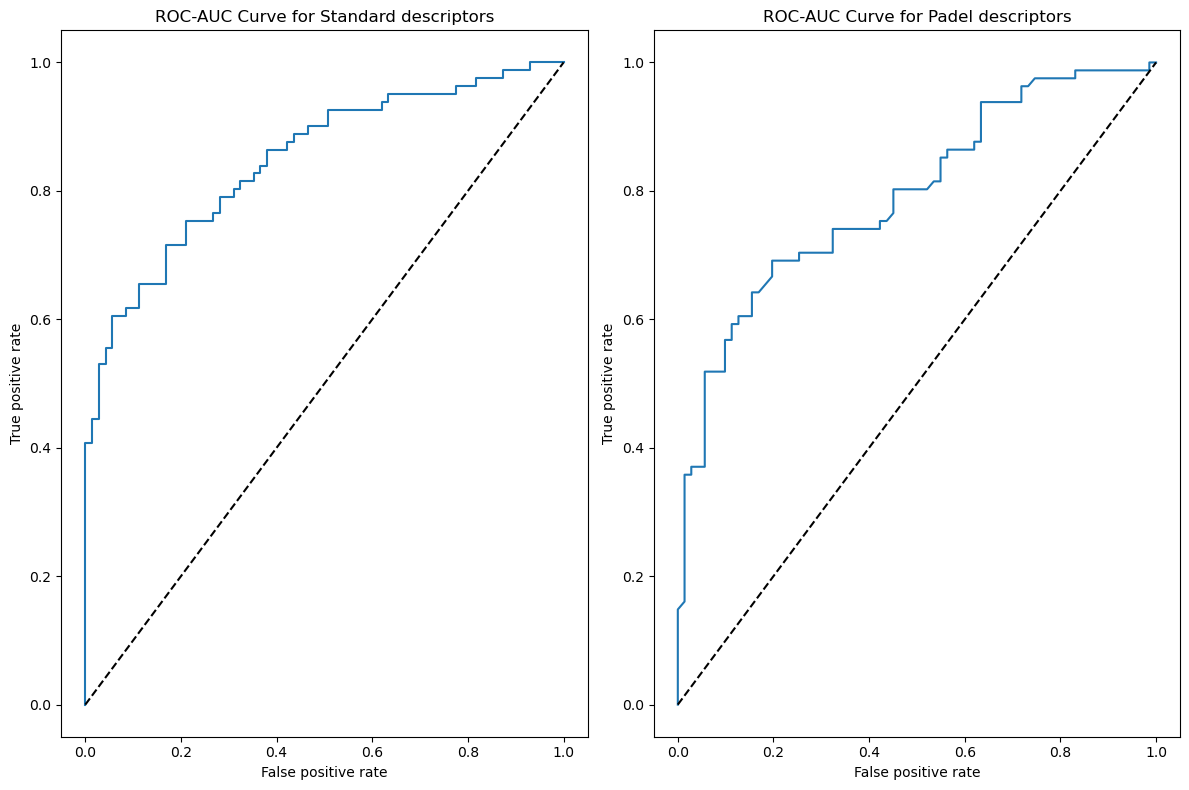

In [80]:
calculate_to_score(RandomForestClassifier(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict,
                   target=target,                   type = 'Full')
               

100%|██████████| 50/50 [04:53<00:00,  5.88s/trial, best loss: -0.6813255071586395]
{'max_depth': 13, 'max_features': 0, 'min_samples_leaf': 3, 'min_samples_split': 5}
100%|██████████| 50/50 [05:02<00:00,  6.05s/trial, best loss: -0.7147960285328707]
{'max_depth': 17, 'max_features': 0, 'min_samples_leaf': 3, 'min_samples_split': 5}


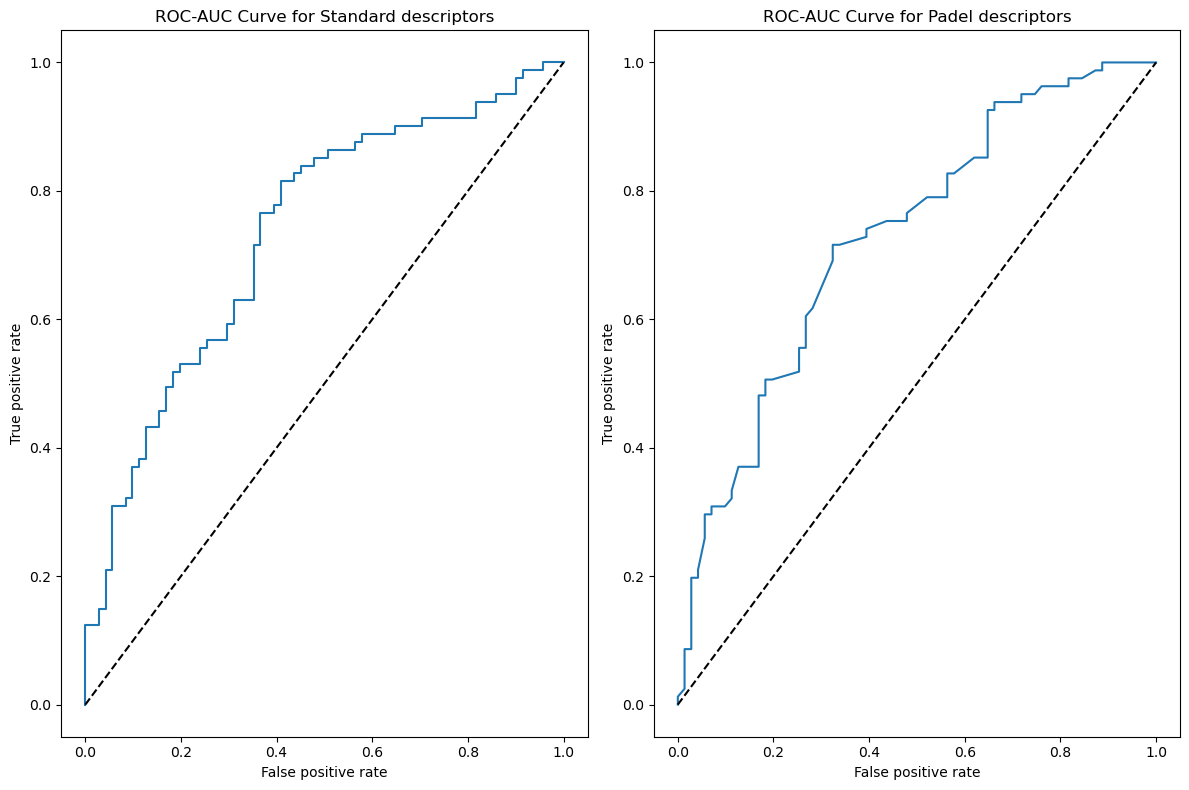

In [81]:
calculate_to_score(RandomForestClassifier(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict_pca,
                   target=target,                   type = 'PCA')


**XGBoost**

In [82]:
space = {'xgbclassifier__n_estimators':hp.randint('n_estimators', 1, 30),
         'xgbclassifier__learning_rate': hp.loguniform('learning_rate', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__reg_alpha':hp.loguniform(label = 'reg_alpha', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__max_depth':hp.randint('max_depth', 1, 100)}

 14%|█▍        | 7/50 [00:11<01:04,  1.51s/trial, best loss: -0.7848510638297872]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 26%|██▌       | 13/50 [00:20<00:57,  1.56s/trial, best loss: -0.7848510638297872]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 98%|█████████▊| 49/50 [01:19<00:02,  2.06s/trial, best loss: -0.8117484051254475]

...

 40%|████      | 20/50 [00:21<00:21,  1.38trial/s, best loss: -0.8414552767493945]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 70%|███████   | 35/50 [00:42<00:16,  1.12s/trial, best loss: -0.8414552767493945]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [01:02<00:00,  1.24s/trial, best loss: -0.8414552767493945]
{'learning_rate': 0.8651530556990966, 'max_depth': 17, 'n_estimators': 24, 'reg_alpha': 0.018052894349004464}


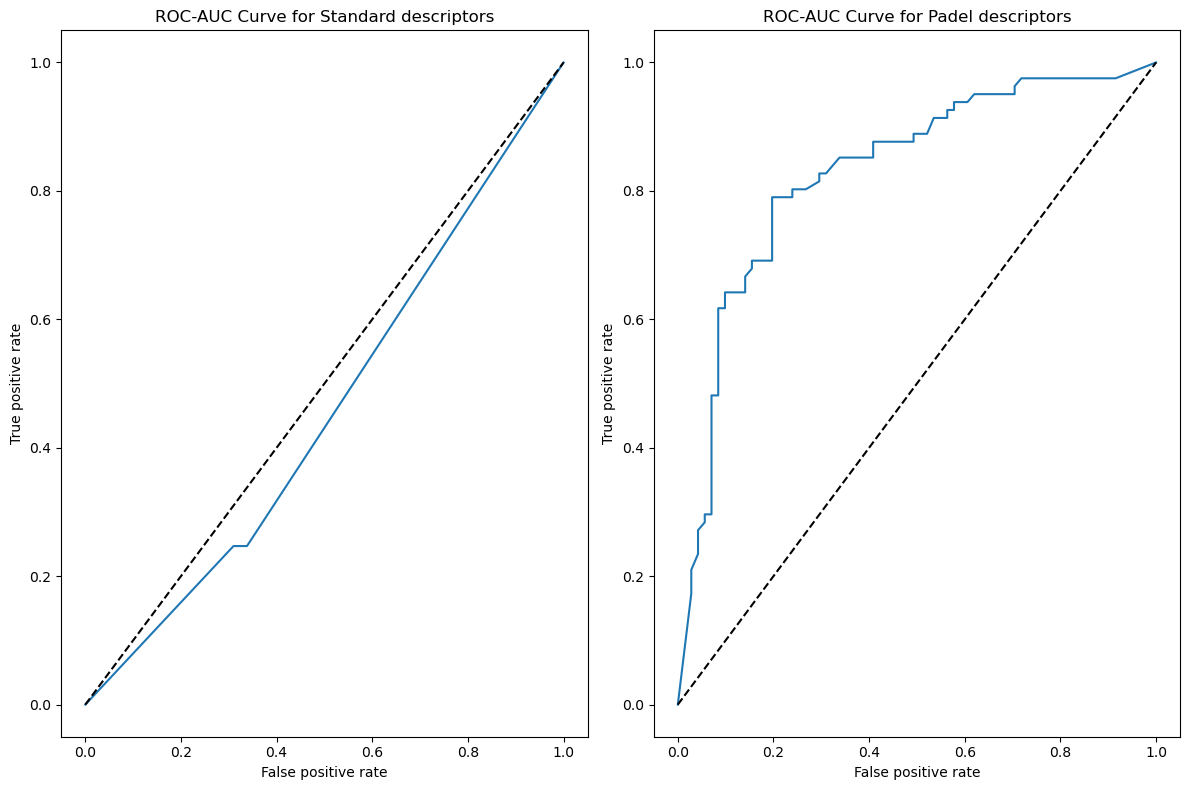

In [83]:
calculate_to_score(XGBClassifier(n_jobs = -1), estimator_name='Gradient boosting', param_grid = space,
                   descriptors_dict=descriptors_dict,
                   target=target,
                   type = 'Full')

 40%|████      | 20/50 [01:31<01:51,  3.72s/trial, best loss: -0.709452616349168] 

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 44%|████▍     | 22/50 [01:34<01:16,  2.73s/trial, best loss: -0.709452616349168]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 58%|█████▊    | 29/50 [01:57<01:16,  3.66s/trial, best loss: -0.709452616349168]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 84%|████████▍ | 42/50 [02:39<00:19,  2.39s/trial, best loss: -0.709452616349168]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [03:10<00:00,  3.81s/trial, best loss: -0.709452616349168]
{'learning_rate': 2.618273233249931, 'max_depth': 66, 'n_estimators': 25, 'reg_alpha': 0.21827788841393003}
100%|██████████| 50/50 [03:55<00:00,  4.70s/trial, best loss: -0.6837165514797093]
{'learning_rate': 0.19800846393674798, 'max_depth': 53, 'n_estimators': 23, 'reg_alpha': 0.009818458995610421}


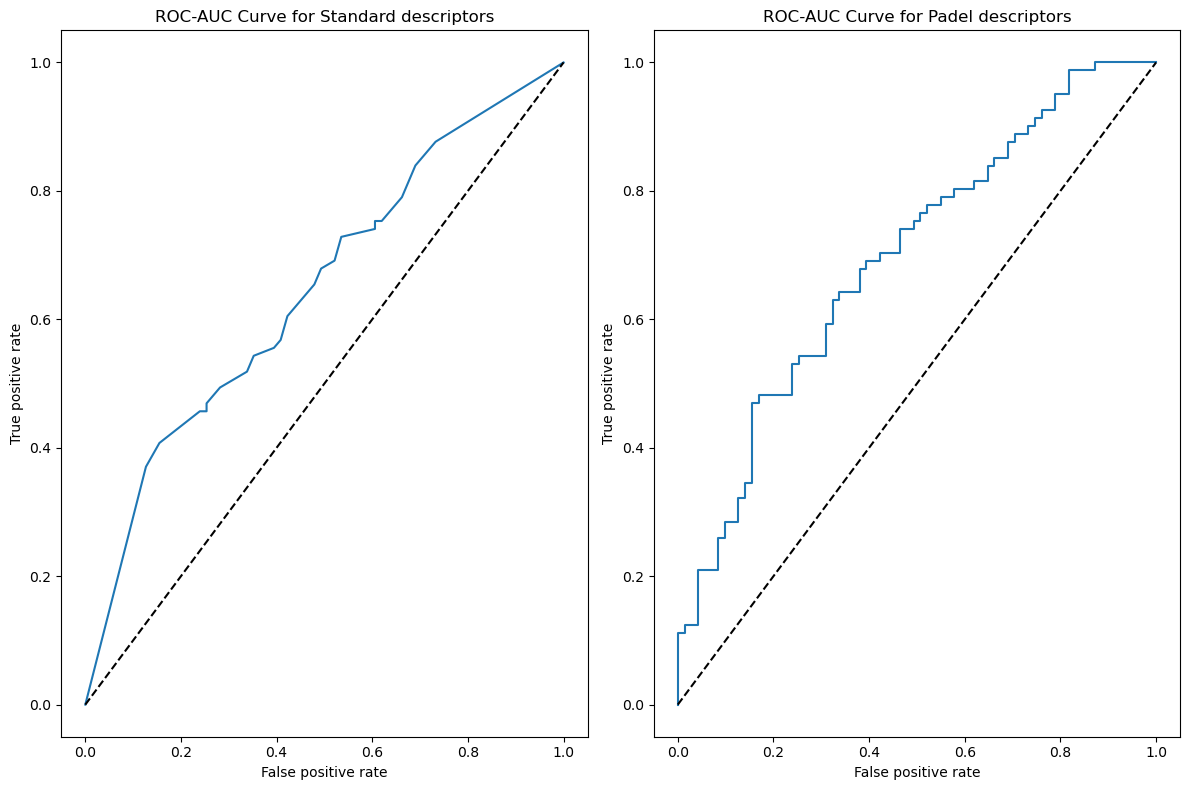

In [84]:
calculate_to_score(XGBClassifier(n_jobs = -1), estimator_name='Gradient boosting', param_grid = space,
                   descriptors_dict=descriptors_dict_pca,
                   target=target,
                   type = 'PCA')

**SVM**

In [85]:
space = {'svc__C':hp.loguniform('C', -3*np.log(10), 2*np.log(10)),
         'svc__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svc__degree':hp.choice('degree', [2,3, 4]),
         'svc__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svc__coef0':hp.loguniform('coef0', -3*np.log(10), 0*np.log(10))}

100%|██████████| 50/50 [03:51<00:00,  4.63s/trial, best loss: -0.7310115350488021]
{'C': 8.625854191912211, 'coef0': 0.08896969525620231, 'degree': 2, 'gamma': 0, 'kernel': 2}
100%|██████████| 50/50 [02:48<00:00,  3.36s/trial, best loss: -0.7386167526044407]
{'C': 9.643670383828573, 'coef0': 0.009303702993517378, 'degree': 2, 'gamma': 0, 'kernel': 1}


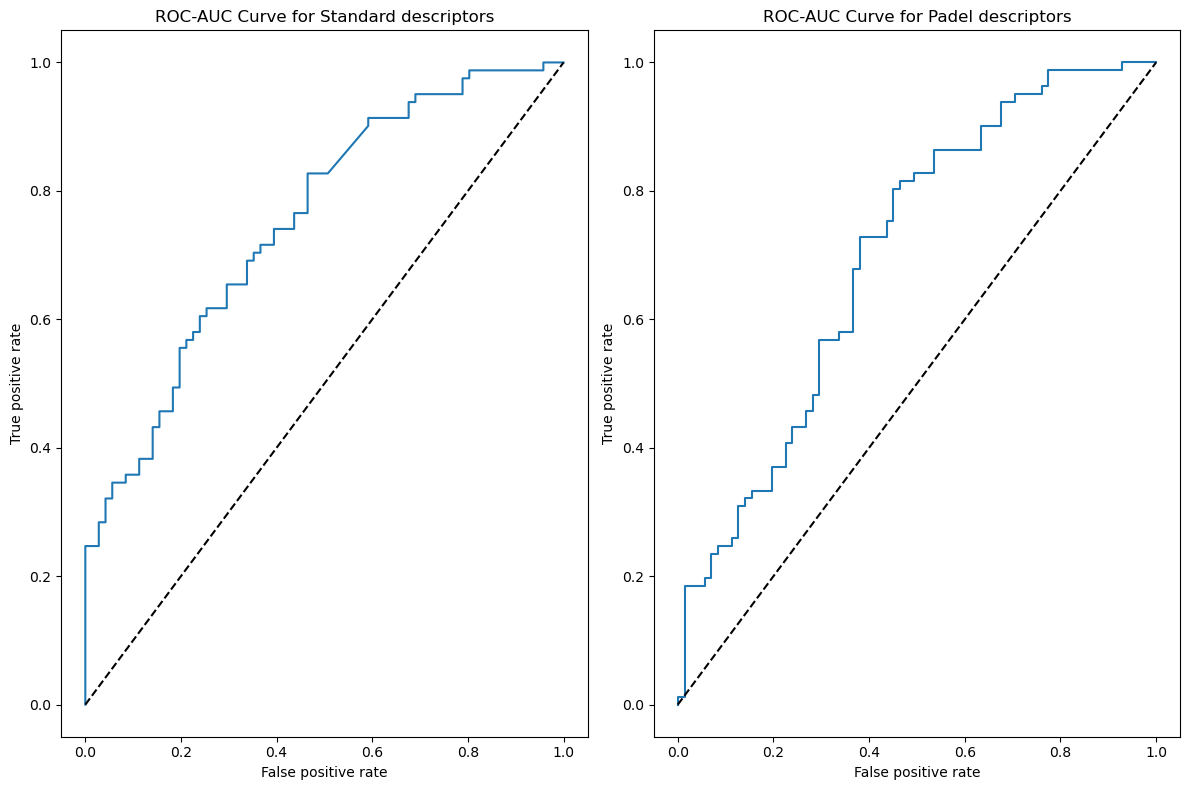

In [86]:
calculate_to_score(SVC(probability=True), estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict, target = target, type = 'Full')
                                                                


100%|██████████| 50/50 [01:40<00:00,  2.01s/trial, best loss: -0.6250436369464872]
{'C': 83.67594910507145, 'coef0': 0.019228705441751023, 'degree': 0, 'gamma': 1, 'kernel': 0}
100%|██████████| 50/50 [01:38<00:00,  1.98s/trial, best loss: -0.5253724053724054]
{'C': 0.8812304492157857, 'coef0': 0.0453406801423764, 'degree': 0, 'gamma': 1, 'kernel': 1}


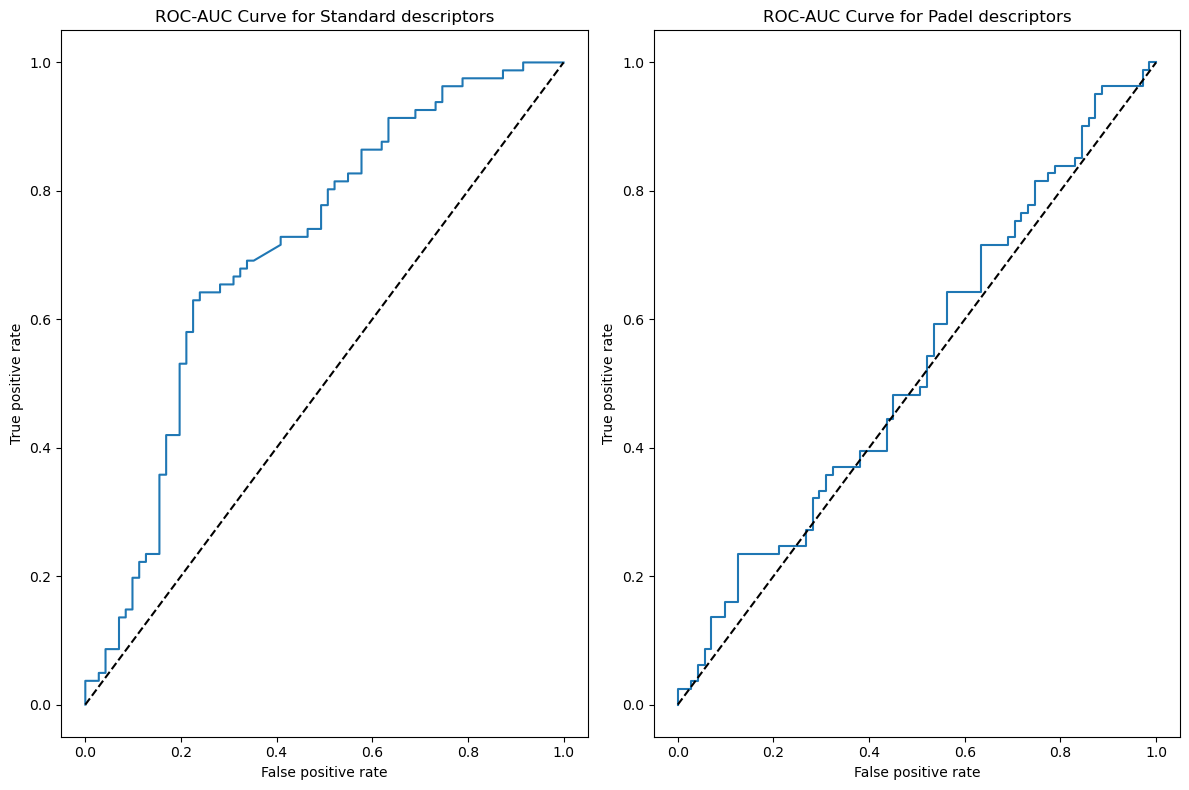

In [87]:
calculate_to_score(SVC(probability=True), estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict_pca, target = target, type = 'PCA')


**KNearestneighbors**

In [88]:
space = {'kneighborsclassifier__n_neighbors':hp.randint('n_neighbors',1, 10),
         'kneighborsclassifier__weights':hp.choice('weights', ['uniform', 'distance']),
         'kneighborsclassifier__metric':hp.choice('metric', ['minkowski', 'chebyshev', 'cosine', 'euclidean'])}


100%|██████████| 50/50 [00:21<00:00,  2.36trial/s, best loss: -0.7323262548262548]
{'metric': 2, 'n_neighbors': 2, 'weights': 0}
100%|██████████| 50/50 [00:15<00:00,  3.26trial/s, best loss: -0.7816267942583732]
{'metric': 2, 'n_neighbors': 2, 'weights': 0}


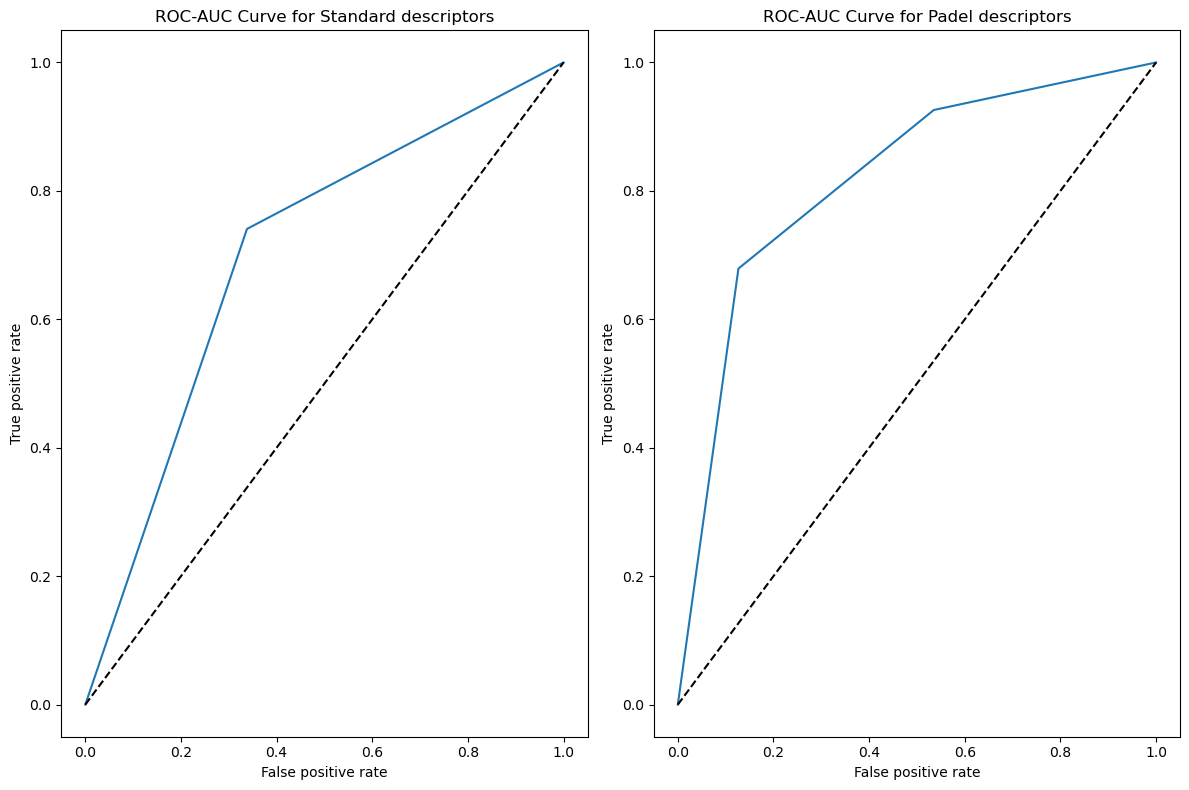

In [89]:
calculate_to_score(KNeighborsClassifier(), estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict, target=target, type = 'Full')

100%|██████████| 50/50 [00:07<00:00,  6.50trial/s, best loss: -0.5729144189868546]
{'metric': 2, 'n_neighbors': 4, 'weights': 0}
  8%|▊         | 4/50 [00:00<00:06,  7.55trial/s, best loss: -0.6721485411140583]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 12%|█▏        | 6/50 [00:00<00:07,  6.23trial/s, best loss: -0.6721485411140583]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 24%|██▍       | 12/50 [00:01<00:06,  5.73trial/s, best loss: -0.6721485411140583]

...

 84%|████████▍ | 42/50 [00:05<00:01,  6.68trial/s, best loss: -0.6721485411140583]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [00:07<00:00,  6.98trial/s, best loss: -0.6721485411140583]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




{'metric': 2, 'n_neighbors': 9, 'weights': 1}


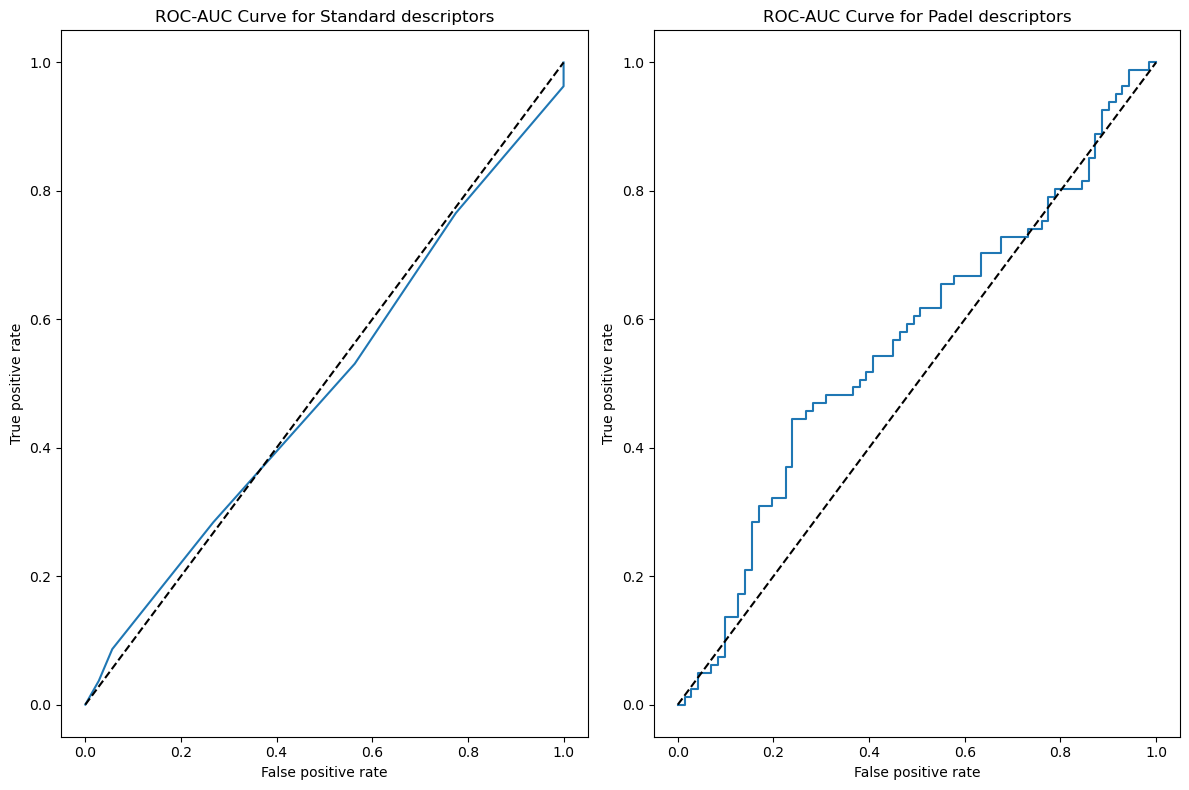

In [90]:
calculate_to_score(KNeighborsClassifier(), estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict_pca, target=target, type = 'PCA')

Let's save results into pickle file and show the final scores model in readable format

In [91]:
with open('score_hyper_opt.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [92]:
pd.DataFrame(scores)

,Descriptors,Full or PCA,Accuracy,F1 - score,ROC-AUC Score,Estimator,Recall score,Precision score
0,Standard,Full,0.710526,0.728395,0.757086,Logistic Regression,0.728395,0.728395
1,Padel,Full,0.671053,0.712644,0.745436,Logistic Regression,0.765432,0.666667
2,Standard,PCA,0.644737,0.682353,0.704051,Logistic Regression,0.716049,0.651685
3,Padel,PCA,0.532895,0.695279,0.524778,Logistic Regression,1.000000,0.532895
4,Standard,Full,0.743421,0.757764,0.847157,Random Forest,0.753086,0.762500
5,Padel,Full,0.671053,0.709302,0.791688,Random Forest,0.753086,0.670330
6,Standard,PCA,0.664474,0.735751,0.734133,Random Forest,0.876543,0.633929
7,Padel,PCA,0.651316,0.700565,0.725961,Random Forest,0.765432,0.645833
8,Standard,Full,0.453947,0.325203,0.457920,Gradient boosting,0.246914,0.476190
9,Padel,Full,0.710526,0.763441,0.829073,Gradient boosting,0.876543,0.676190


As we can see, simple KMeans model with Padel regressors with following parameters:  
**{'metric': 2, 'n_neighbors': 2, 'weights': 0}**  
Shows the best performance in terms of precision and can be applied further to predict if the system is geleous under studied conditions